In [2]:
import numpy as np
import pandas as pd

In [3]:
data = pd.read_parquet("../data/ward_rounds.parquet")

data.head()

,reg_id,birth_year,gender,case_id,timestamp,bmt_days,bmt_timestamp,descr
0,2162333251657786212,2010,M,9706589495990996388,2016-03-15,-72,2016-05-26,Обход совместно с: руководителем отдела ДОГиТ ...
1,2162333251657786212,2010,M,9706589495990996388,2016-03-16,-71,2016-05-26,Обход совместно с: руководителем отдела ДОГиТ ...
2,2162333251657786212,2010,M,9706589495990996388,2016-03-23,-64,2016-05-26,Обход совместно с: руководителем отдела ДОГиТ ...
3,2162333251657786212,2010,M,9706589495990996388,2016-04-05,-51,2016-05-26,Обход совместно с: руководителем отдела ДОГиТ ...
4,2162333251657786212,2010,M,9706589495990996388,2016-04-13,-43,2016-05-26,Обход совместно с: руководителем отдела ДОГиТ ...


In [7]:
from collections import defaultdict


bmt_dict = defaultdict(int)
bounds = [(x, x+300) for x in range(-600, 5_000, 300)]
bmt_days = data['bmt_days'].to_numpy()

for day in bmt_days:
    for l, r in bounds:
        if (day > l) and (day <= r):
            bmt_dict[(l, r)] += 1
bmt_dict

defaultdict(int,
            {(-300, 0): 6226,
             (300, 600): 3025,
             (2100, 2400): 153,
             (2400, 2700): 76,
             (0, 300): 15172,
             (900, 1200): 901,
             (600, 900): 1522,
             (2700, 3000): 74,
             (3000, 3300): 87,
             (3300, 3600): 50,
             (1200, 1500): 589,
             (1500, 1800): 382,
             (-600, -300): 195,
             (4200, 4500): 20,
             (1800, 2100): 267,
             (4500, 4800): 17,
             (3900, 4200): 48,
             (3600, 3900): 59})

In [ ]:

bins = [-np.inf, 0, 30, 100, 365, np.inf]
labels = ['Pre-BMT', 'Early_Acute', 'Mid_Acute', 'Early_Chronic', 'Long_term']

data['clinical_stage'] = pd.cut(data['bmt_days'], bins=bins, labels=labels)


target_dist = {
    'Pre-BMT': 100,
    'Early_Acute': 150, 
    'Mid_Acute': 100,
    'Early_Chronic': 90,
    'Long_term': 60
}


gold_samples = []

for stage, count in target_dist.items():
    subset = data[data['clinical_stage'] == stage]
    if not subset.empty:
        # Сэмплим по пациентам, чтобы не брать одного и того же
        unique_regs = subset['reg_id'].unique()
        chosen_regs = np.random.choice(unique_regs, min(len(unique_regs), count), replace=False)
        sample = subset[subset['reg_id'].isin(chosen_regs)].groupby('reg_id').head(1)
        gold_samples.append(sample)

gold_df = pd.concat(gold_samples).sample(frac=1) #.reset_index(drop=True)

In [5]:
gold_df.to_parquet("../data/data2thesaurus_small.parquet")

In [3]:
data_gold = pd.read_parquet("../data/data2thesaurus.parquet")
data_gold.head()

,reg_id,birth_year,gender,case_id,timestamp,bmt_days,bmt_timestamp,descr,clinical_stage
18091,2450932301640898223,2006,M,3729282332158546837,2014-08-01,107,2014-04-16,Обход совместно с: руководителем отдела ГОиТПВ...,Early_Chronic
23215,16810118348450963270,1980,M,1499294970933199490,2017-03-29,22,2017-03-07,Обход совместно с: директором НИИ ДОГиТ им. Р....,Early_Acute
5312,17484336191866679309,1993,M,4261629062314915051,2022-12-02,380,2021-11-17,Обход совместно с: директором НИИ ДОГиТ им. Р....,Long_term
19335,6704277286472924981,1957,M,3349123712252366706,2016-04-06,231,2015-08-19,Обход совместно с: зам. директора НИИДОГиТ по ...,Early_Chronic
1549,9112911214959460635,1963,M,4792851645848403166,2024-07-04,3,2024-07-01,Обход совместно с: руководителем отделения к.м...,Early_Acute


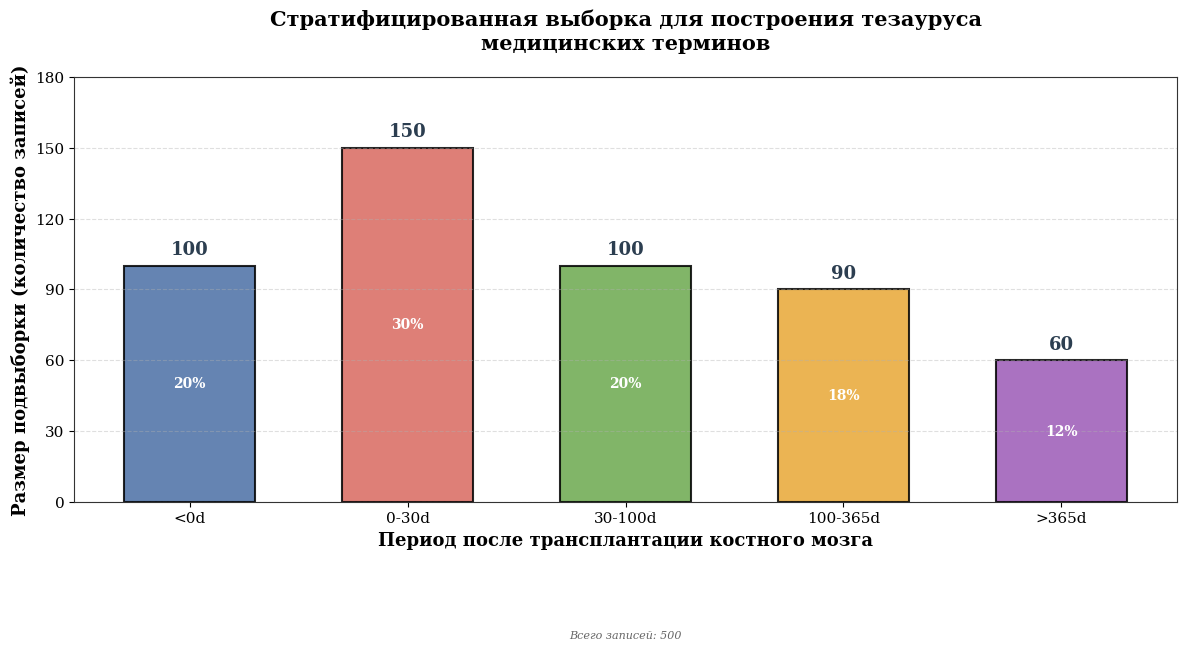

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


target_dist = {
    'Pre-BMT': 100,
    'Early_Acute': 150,
    'Mid_Acute': 100,
    'Early_Chronic': 90,
    'Long_term': 60
}


periods = ['<0d', '0-30d', '30-100d', 
           '100-365d', '>365d']
sizes = [target_dist['Pre-BMT'], target_dist['Early_Acute'], 
         target_dist['Mid_Acute'], target_dist['Early_Chronic'], 
         target_dist['Long_term']]


colors = ['#4A6FA5', '#D9695F', '#6BA84E', '#E8A735', '#9B59B6']


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#333333'

fig, ax = plt.subplots(figsize=(12, 7))


bars = ax.bar(periods, sizes, color=colors, edgecolor='black', 
              linewidth=1.5, alpha=0.85, width=0.6)


for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{size}', ha='center', va='bottom', fontsize=13, 
            fontweight='bold', color='#2c3e50')


total = sum(sizes)  # 500
for bar, size in zip(bars, sizes):
    pct = (size / total) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{pct:.0f}%', ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')


ax.set_ylabel('Размер подвыборки (количество записей)', fontsize=13, fontweight='bold')
ax.set_xlabel('Период после трансплантации костного мозга', fontsize=13, fontweight='bold')
ax.set_title('Стратифицированная выборка для построения тезауруса\n' +
             'медицинских терминов', fontsize=15, fontweight='bold', pad=20)


ax.set_ylim(0, 170)
ax.set_yticks(range(0, 181, 30))
ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.8)


ax.text(0.5, -0.32, f'Всего записей: {total}',
        transform=ax.transAxes, ha='center', fontsize=8, 
        color='#666666', style='italic')

plt.tight_layout()
plt.show()

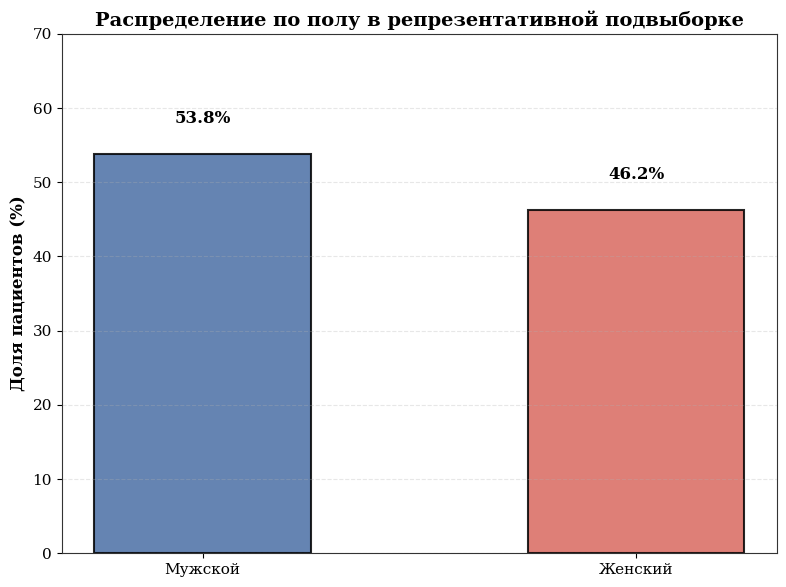

In [14]:
import pandas as pd

data_gold = pd.read_parquet("../data/data2thesaurus.parquet")

fig, ax = plt.subplots(figsize=(8, 6))

# Только подвыборка
gender_sample = data_gold['gender'].to_numpy()
sample_counts = pd.Series(gender_sample).value_counts(normalize=True) * 100

categories = ['Мужской', 'Женский']
values = [sample_counts.get(1, 0) if 1 in sample_counts else sample_counts.get('M', 0),
          sample_counts.get(2, 0) if 2 in sample_counts else sample_counts.get('F', 0)]

bars = ax.bar(categories, values, color=['#4A6FA5', '#D9695F'], 
              edgecolor='black', linewidth=1.5, alpha=0.85, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%\n', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Доля пациентов (%)', fontsize=12, fontweight='bold')
ax.set_title('Распределение по полу в репрезентативной подвыборке', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 70)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
bins = [-np.inf, 0, 30, 100, 365, np.inf]
labels = ['Pre-BMT', 'Early_Acute', 'Mid_Acute', 'Early_Chronic', 'Long_term']

data['clinical_stage'] = pd.cut(data['bmt_days'], bins=bins, labels=labels)

target_dist = {
    'Pre-BMT': 20,
    'Early_Acute': 50,
    'Mid_Acute': 20,
    'Early_Chronic': 5,
    'Long_term': 5
}


gold_samples = []

for stage, count in target_dist.items():
    subset = data[data['clinical_stage'] == stage]
    if subset.empty:
        continue
        
    unique_regs = subset['reg_id'].unique()
    
    chosen_regs = np.random.choice(
        unique_regs, 
        min(len(unique_regs), count), 
        replace=False
    )
    
    sample = (
        subset[subset['reg_id'].isin(chosen_regs)]
        .groupby('reg_id')
        .head(1)
    )
    
    
    while not sample.empty and any(sample.apply(tuple, 1).isin(data2th.apply(tuple, 1))):
        chosen_regs = np.random.choice(
            unique_regs, 
            min(len(unique_regs), count), 
            replace=False
        )
        sample = (
            subset[subset['reg_id'].isin(chosen_regs)]
            .groupby('reg_id')
            .head(1)
        )
    
    gold_samples.append(sample)


forindex_df = pd.concat(gold_samples).sample(frac=1) #.reset_index(drop=True)

In [61]:
forindex_df.to_parquet("../data/data2indexing_small_clean.parquet")

In [62]:
import pandas as pd

forindex_df = pd.read_parquet("../data/data2indexing_small_clean.parquet")
forindex_df

,reg_id,birth_year,gender,case_id,timestamp,bmt_days,bmt_timestamp,descr,clinical_stage
16262,4916428980535602061,1989,F,3747262977168847183,2018-09-25,383,2017-09-07,Обход совместно с: зав. отделением ТКМ для взр...,Long_term
12960,3134398391787225792,1997,M,18183843373938632047,2015-03-17,-7,2015-03-24,Обход совместно с: директором НИИ ДОГиТ им. Р....,Pre-BMT
24989,2356037514002751612,2001,F,1316354751565242414,2019-08-30,31,2019-07-30,Обход совместно с: заместителем директора по н...,Mid_Acute
27483,6334594449636287523,2003,M,16468192354312698045,2016-04-19,22,2019-11-28,"Обход совместно с: к.м.н., главным детским онк...",Early_Acute
15686,7428038284915799600,2002,M,9007812258692600455,2017-08-02,41,2017-06-22,Обход совместно с: руководителем отдела онколо...,Mid_Acute
...,...,...,...,...,...,...,...,...,...
25338,4141580952927286256,1978,F,9280523921025606133,2023-02-02,70,2022-11-24,Обход совместно с: зам. директора НИИДОГиТ по ...,Mid_Acute
17770,15319540792583192730,1976,F,8635219544677941088,2019-06-20,2,2019-06-18,Обход совместно с: директором НИИ ДОГиТ им. Р....,Early_Acute
8225,10095121539069619342,1989,F,14963931508883678260,2024-09-03,32,2024-08-02,Обход совместно с: зам. директора НИИДОГиТ по ...,Mid_Acute
10232,9223443311416430315,1976,F,11505942040846402020,2017-05-26,272,2016-08-27,Обход совместно с: директором НИИ ДОГиТ им. Р....,Early_Chronic


In [63]:
data2th = pd.read_parquet("../data/data2thesaurus.parquet")

data2th_index = data2th.index.to_list()

In [64]:
total = 0
for i, row in forindex_df.iterrows():
    if i in data2th_index:
        total += 1

total

0